# Spectra Comparison

Load one multilayer dataset shard and plot 20 matching `NRA` and `RBS` spectra to compare their structure.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

if str(Path.cwd().parent) not in sys.path:
    sys.path.append(str(Path.cwd().parent))

from ibamlkit.data import DatasetBatchReader

In [10]:
candidate_paths = [
    Path.cwd() / "datasets" / "multilayer_14_elements" / "layers_10" / "multilayer_10_000001.h5",
    Path.cwd() / "examples" / "datasets" / "multilayer_14_elements" / "layers_10" / "multilayer_10_000001.h5",
]

dataset_path = next((path.resolve() for path in candidate_paths if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Could not locate multilayer_10_000001.h5 from the current working directory.")

reader = DatasetBatchReader()
dataset = reader.load_many([dataset_path])
reader.print_summary(dataset, [dataset_path])
print("Dataset path:", dataset_path)

Loaded 1 file(s)
Samples: 100000
Methods: ['NRA', 'RBS']
Open parameters: ['Thickness_1', 'Conc_1_Li', 'Conc_1_C', 'Conc_1_O', 'Conc_1_F', 'Conc_1_Si', 'Conc_1_P', 'Conc_1_Fe', 'Conc_1_Al', 'Conc_1_Mn', 'Conc_1_Sr', 'Conc_1_Ti', 'Conc_1_K', 'Conc_1_Ca', 'Conc_1_Cu', 'Thickness_2', 'Conc_2_Li', 'Conc_2_C', 'Conc_2_O', 'Conc_2_F', 'Conc_2_Si', 'Conc_2_P', 'Conc_2_Fe', 'Conc_2_Al', 'Conc_2_Mn', 'Conc_2_Sr', 'Conc_2_Ti', 'Conc_2_K', 'Conc_2_Ca', 'Conc_2_Cu', 'Thickness_3', 'Conc_3_Li', 'Conc_3_C', 'Conc_3_O', 'Conc_3_F', 'Conc_3_Si', 'Conc_3_P', 'Conc_3_Fe', 'Conc_3_Al', 'Conc_3_Mn', 'Conc_3_Sr', 'Conc_3_Ti', 'Conc_3_K', 'Conc_3_Ca', 'Conc_3_Cu', 'Thickness_4', 'Conc_4_Li', 'Conc_4_C', 'Conc_4_O', 'Conc_4_F', 'Conc_4_Si', 'Conc_4_P', 'Conc_4_Fe', 'Conc_4_Al', 'Conc_4_Mn', 'Conc_4_Sr', 'Conc_4_Ti', 'Conc_4_K', 'Conc_4_Ca', 'Conc_4_Cu', 'Thickness_5', 'Conc_5_Li', 'Conc_5_C', 'Conc_5_O', 'Conc_5_F', 'Conc_5_Si', 'Conc_5_P', 'Conc_5_Fe', 'Conc_5_Al', 'Conc_5_Mn', 'Conc_5_Sr', 'Conc_5_Ti', 'Co

In [11]:
available_methods = list(dataset.spectra.keys())
required_methods = ["NRA", "RBS"]
missing_methods = [name for name in required_methods if name not in available_methods]
if missing_methods:
    raise KeyError(f"Dataset is missing required methods: {missing_methods}. Available methods: {available_methods}")

sample_count = dataset.sample_count
plot_count = min(20, sample_count)
sample_indices = np.linspace(0, sample_count - 1, num=plot_count, dtype=int)
print("Selected sample indices:", sample_indices.tolist())

Selected sample indices: [0, 5263, 10526, 15789, 21052, 26315, 31578, 36841, 42104, 47367, 52631, 57894, 63157, 68420, 73683, 78946, 84209, 89472, 94735, 99999]


In [12]:
def spectrum_view(method_name: str, sample_index: int) -> tuple[np.ndarray, np.ndarray]:
    spectra = np.asarray(dataset.spectra[method_name], dtype=np.float32)
    if dataset.spectra_lengths is None:
        length = spectra.shape[1]
    else:
        length = int(dataset.spectra_lengths[method_name][sample_index])
    y = spectra[sample_index, :length]
    x = np.arange(length, dtype=np.int32)
    return x, y


def print_method_stats(method_name: str) -> None:
    spectra = np.asarray(dataset.spectra[method_name], dtype=np.float32)
    print(f"{method_name}: matrix shape={spectra.shape}, dtype={spectra.dtype}")
    if dataset.spectra_lengths is not None:
        lengths = np.asarray(dataset.spectra_lengths[method_name], dtype=np.int32)
        print(
            f"  lengths: min={int(lengths.min())}, max={int(lengths.max())}, mean={float(lengths.mean()):.2f}"
        )
    print(
        f"  values: min={float(spectra.min()):.6g}, max={float(spectra.max()):.6g}, mean={float(spectra.mean()):.6g}"
    )


for method_name in required_methods:
    print_method_stats(method_name)

NRA: matrix shape=(100000, 744), dtype=float32
  lengths: min=0, max=744, mean=632.09
  values: min=0, max=2.25377e+08, mean=1.1293e+07
RBS: matrix shape=(100000, 2995), dtype=float32
  lengths: min=0, max=2995, mean=2579.83
  values: min=0, max=9.85625e+07, mean=3.95442e+06


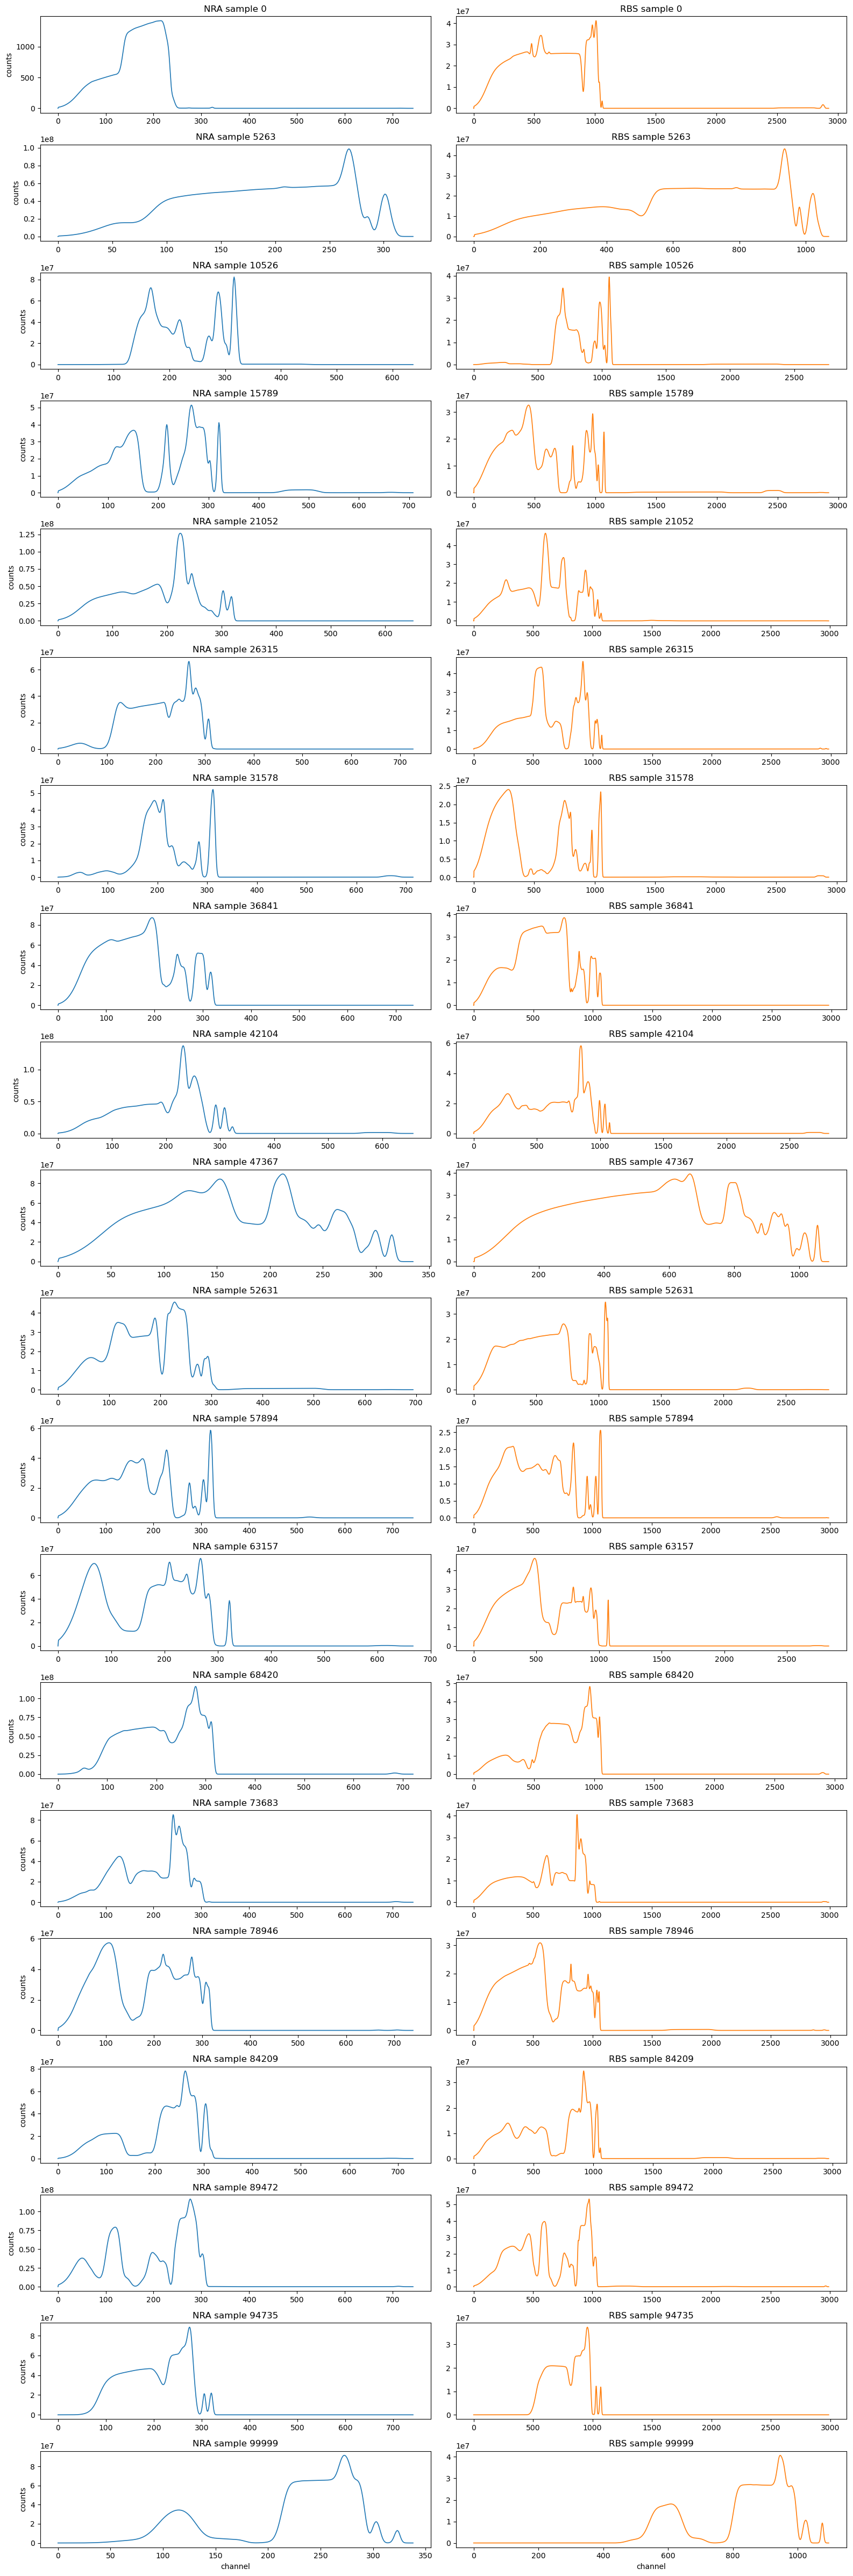

In [13]:
fig, axes = plt.subplots(plot_count, 2, figsize=(16, 2.4 * plot_count), sharex=False)
if plot_count == 1:
    axes = np.asarray([axes])

for row_index, sample_index in enumerate(sample_indices):
    x_nra, y_nra = spectrum_view("NRA", int(sample_index))
    x_rbs, y_rbs = spectrum_view("RBS", int(sample_index))

    axes[row_index, 0].plot(x_nra, y_nra, color="tab:blue", linewidth=1.2)
    axes[row_index, 0].set_title(f"NRA sample {sample_index}")
    axes[row_index, 0].set_ylabel("counts")

    axes[row_index, 1].plot(x_rbs, y_rbs, color="tab:orange", linewidth=1.2)
    axes[row_index, 1].set_title(f"RBS sample {sample_index}")

for axis in axes[-1, :]:
    axis.set_xlabel("channel")

plt.tight_layout()
plt.show()